Contraste

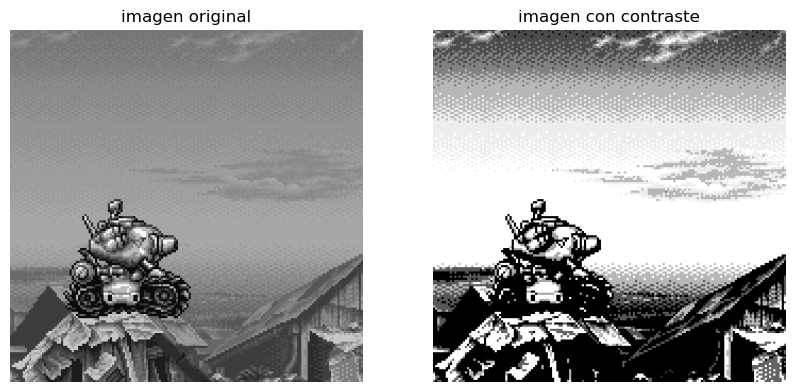

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contraste(img,factor=1.0):
    img=img.astype(np.float32)
    media = np.mean(img)
    img_contraste =media + (img-media)*factor
    img_contraste =np.clip(img_contraste,0,255).astype(np.uint8)
    return img_contraste

imagen = cv2.imread('imgGIF3.jpg',0)

factor_contraste = 6
img_nueva = contraste(imagen,factor_contraste)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(imagen,cmap='gray')
plt.title('imagen original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_nueva,cmap='gray')
plt.title('imagen con contraste')
plt.axis('off')

plt.show()

Contraste a Colores

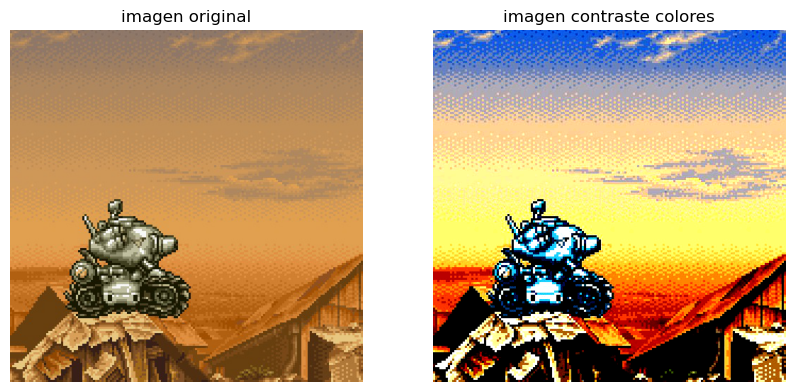

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contrasteColor(img,factor=1.0):
    img=img.astype(np.float32)
    for i in range(3):
        media = np.mean(img[:,:,i])
        img[:,:,i] =media + (img[:,:,i]-media)*factor
        img[:,:,i] =np.clip(img[:,:,i],0,255).astype(np.uint8)

    return img.astype(np.uint8)

imagen = cv2.imread('imgGIF3.jpg')

factor_contraste = 5
img_nueva = contrasteColor(imagen,factor_contraste)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('imagen original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_nueva,cv2.COLOR_BGR2RGB))
plt.title('imagen contraste colores')
plt.axis('off')

plt.show()

Brillo de una imagen

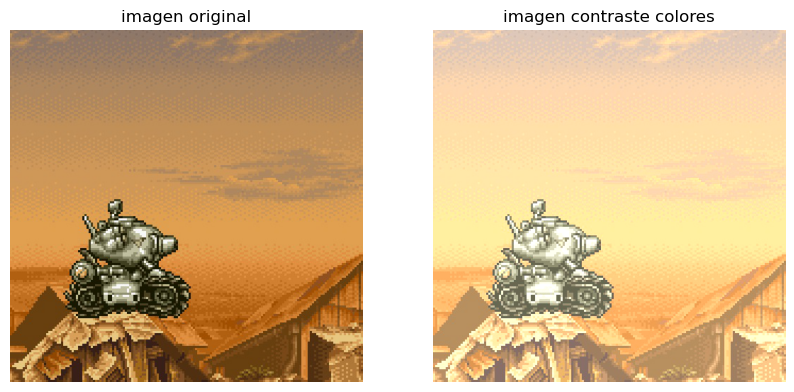

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def brillo(imagen, brillo=0):
    img_brillo = imagen.astype(np.float32)+brillo
    img_brillo = np.clip(img_brillo,0,255).astype(np.uint8)
    return img_brillo

imagen = cv2.imread('imgGIF3.jpg')

factor_brillo = 80
img_nueva = brillo(imagen,factor_brillo)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('imagen original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_nueva,cv2.COLOR_BGR2RGB))
plt.title('imagen brillo')
plt.axis('off')

plt.show()

Contraste y brillo

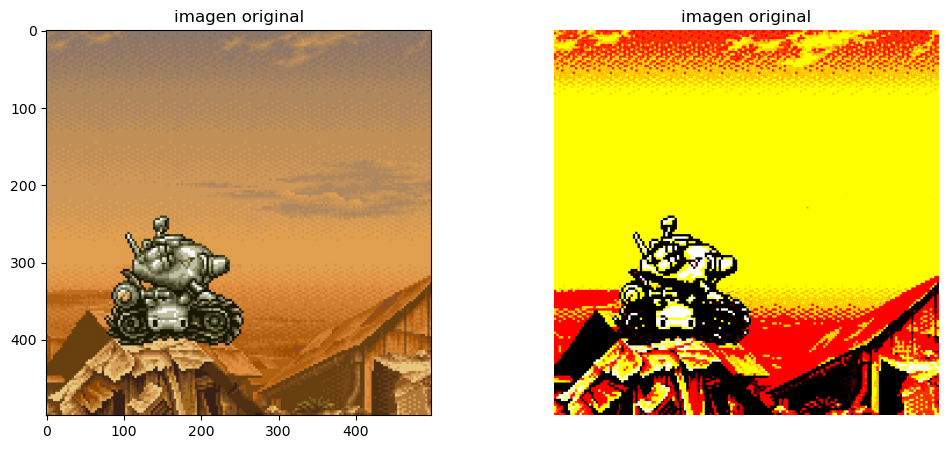

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ajuste(imagen, contraste= 1.0,brillo=0):
    imagen=imagen.astype(np.float32)
    media =np.mean(imagen)
    img_ajust=media+(imagen-media)*contraste+brillo

    img_ajust = np.clip(img_ajust,0,255).astype(np.uint8)
    return img_ajust


imagen = cv2.imread('imgGIF3.jpg')
contraste = 20
brillo = 20
img_nueva = ajuste(imagen,contraste,brillo)

img_rgb = cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)
img_ajustada = cv2.cvtColor(img_nueva,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('imagen original')

plt.subplot(1,2,2)
plt.imshow(img_ajustada)
plt.title('imagen ajustada')
plt.axis('off')

plt.show()

Histograma de uan imagen

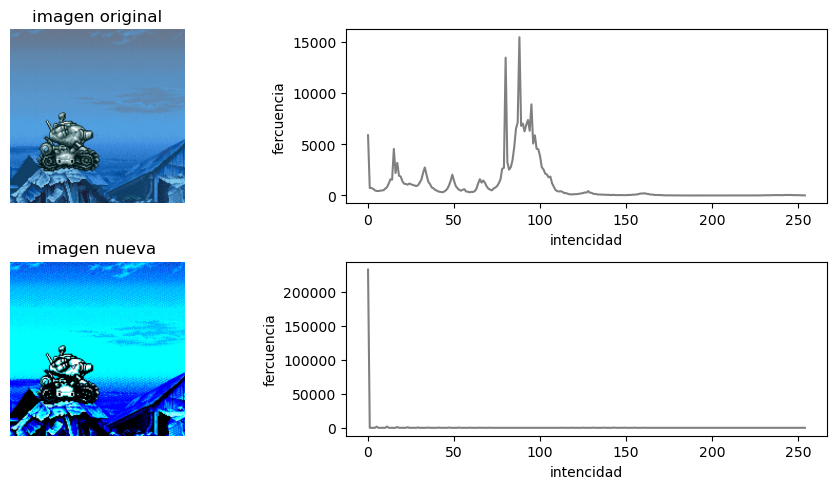

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contraste(imagen,factor=1.0):
    imagen = imagen.astype(np.float32)
    media = np.mean(imagen)
    contrastada = media+(imagen-media)*factor
    contrastada = np.clip(contrastada,0,255).astype(np.uint8)
    return contrastada

imagen = cv2.imread('imgGIF3.jpg')
f_contraste = 6
img_nueva = contraste(imagen,f_contraste)
histogrma_ori = cv2.calcHist([imagen],[0],None,[255],[0,255])
histogrma_contraste= cv2.calcHist([img_nueva],[0],None,[255],[0,255])

plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.imshow(imagen, cmap='gray')
plt.title('imagen original')
plt.axis('off')

plt.subplot(2,2,2)
plt.plot(histogrma_ori,color='gray')
plt.xlabel('intencidad')
plt.ylabel('fercuencia')


plt.subplot(2,2,3)
plt.imshow(img_nueva, cmap='gray')
plt.title('imagen nueva')
plt.axis('off')

plt.subplot(2,2,4)
plt.plot(histogrma_contraste,color='gray')
plt.xlabel('intencidad')
plt.ylabel('fercuencia')

plt.tight_layout()

plt.show()

Ejer1 lectura, punto de interes e histograma en 3 canales

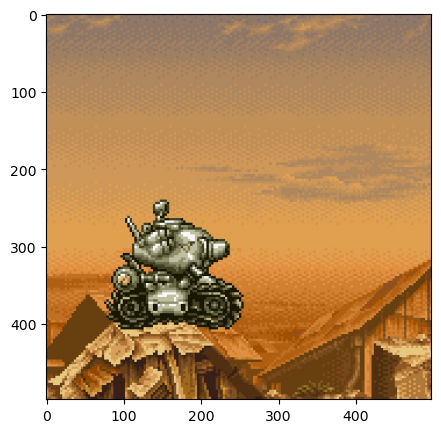

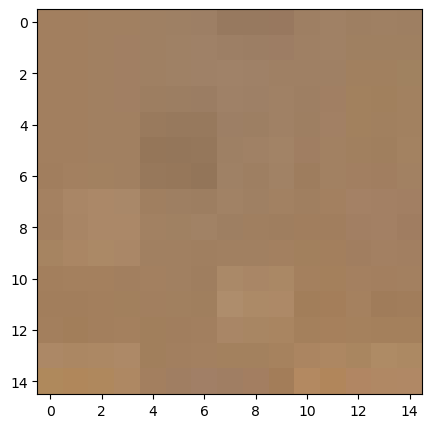

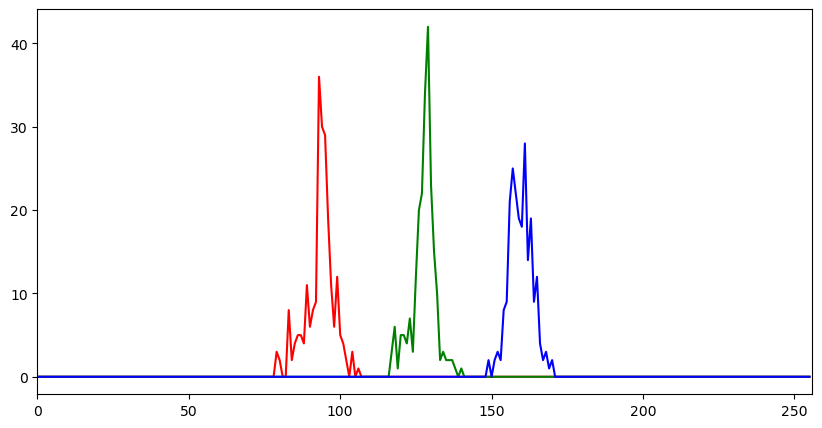

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=[10,5]

imagen = cv2.imread('imgGIF3.jpg')
img_rgb = cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

#punto de interes
plt.imshow(img_rgb[50:65,20:35,:])
plt.show()
#guardando de imagen
img_cortada =img_rgb[50:65,20:35,:]
plt.imsave('img_cortada.jpg',img_cortada)

#histograma
seccionada = plt.imread('img_cortada.jpg')
color = ('r','g','b')
for canal,col in enumerate(color):
    histograma = cv2.calcHist([seccionada*255],[canal],None,[256],[0,256])
    plt.plot(histograma,color=col)
    plt.xlim([0,256])

plt.show()

Mascaras

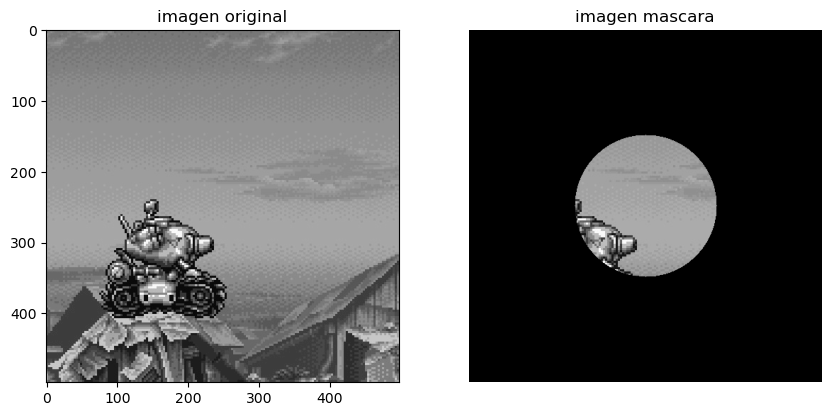

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imgGIF3.jpg',0)

alto,ancho=img.shape[:2]
#crear mascara circular

mascara = np.zeros_like(img)
centro = (ancho//2,alto//2)
radio = 100
cv2.circle(mascara,centro,radio,(255),-1)
img_mascara = cv2.bitwise_and(img,img,mask=mascara)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('imagen original')

plt.subplot(1,2,2)
plt.imshow(img_mascara,cmap='gray')
plt.title('imagen mascara')
plt.axis('off')


plt.show()